In [43]:
%matplotlib inline

from pathlib import Path

import numpy as np
import cv2
from matplotlib import pyplot as plt
from PIL import Image
from IPython.display import display, HTML
import pandas as pd

data_dir = (Path.cwd().parent / ".data/LV_3/camera_calib").resolve()
assert data_dir.exists(), data_dir
plt.rcParams.update({"figure.figsize": (8, 6), "figure.dpi": 120})

In [44]:
img_files = {camera: sorted((data_dir / "imgs" / camera).glob("*.png")) for camera in ["left", "right"]}

assert all(len(v) == 20 for v in img_files.values()), img_files

## Inspect image set
We verify the number of images per camera before inferring the checkerboard configuration automatically.

In [45]:
img_files

{'left': [PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/left/Im_L_1.png'),
  PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/left/Im_L_10.png'),
  PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/left/Im_L_11.png'),
  PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/left/Im_L_12.png'),
  PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/left/Im_L_13.png'),
  PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/left/Im_L_14.png'),
  PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/left/Im_L_15.png'),
  PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/left/Im_L_16.png'),
  PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/left/Im_L_17.png'),
  PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_3/camera_calib/imgs/lef

In [ ]:
def infer_pattern_size(paths, candidates=None, max_images=6):
    """Try multiple checkerboard sizes and pick the one with most detections."""
    if candidates is None:
        candidates = [
            (12, 8),
            (11, 8),
            (11, 7),
            (10, 7),
            (9, 6),
            (8, 6),
            (8, 5),
        ]

    counts = {}
    sample_paths = paths[:max_images] if len(paths) > max_images else paths
    for pattern in candidates:
        successes = 0
        for path in sample_paths:
            img = cv2.imread(str(path))
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            found, _ = cv2.findChessboardCornersSB(
                gray,
                pattern,
                flags=cv2.CALIB_CB_EXHAUSTIVE | cv2.CALIB_CB_ACCURACY,
            )
            if found:
                successes += 1
        counts[pattern] = successes

    best_pattern = max(counts, key=counts.get)
    return best_pattern, counts

pattern_left, counts_left = infer_pattern_size(img_files["left"])
pattern_right, counts_right = infer_pattern_size(img_files["right"])

display(HTML("<h4>Checkerboard inference</h4>"))
display(pd.DataFrame({"left": counts_left, "right": counts_right}).T)
print(f"Selected pattern left: {pattern_left}, right: {pattern_right}")

12 11    10 9  8    
       8  8  7  7  6  6  5
left   0  0  6  0  0  0  0
right  0  0  6  0  0  0  0

Selected pattern left: (11, 7), right: (11, 7)


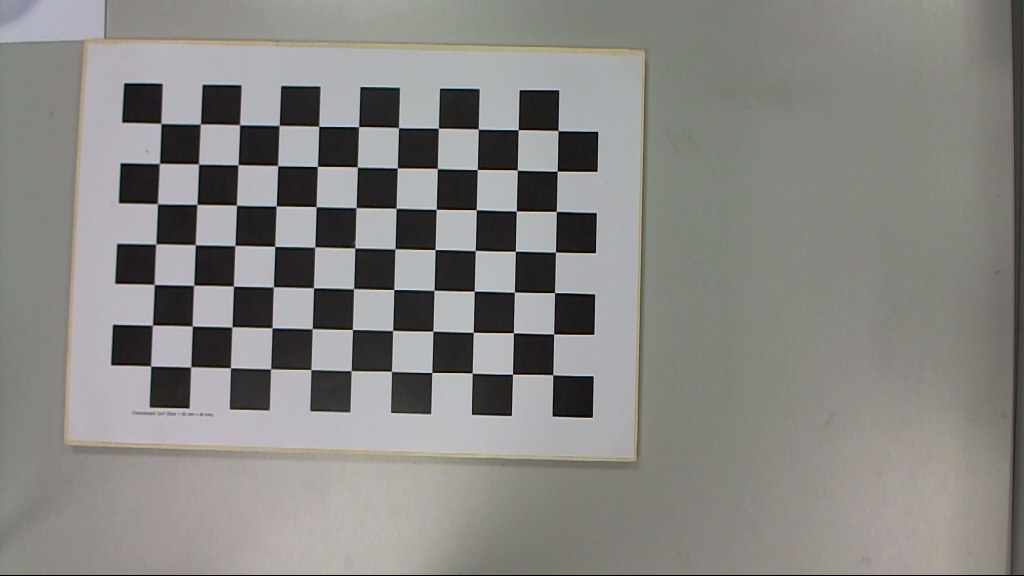

In [47]:
Image.open(img_files["left"][0])

`# rows` = 8,
`# cols` = 12

In [48]:
criteria = (
    +cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, #
    30, # max number of iterations
    0.001, #
)

object_points = np.zeros

In [ ]:
def calibrate_from_paths(
    paths: list[Path],
    pattern_size: tuple[int, int] = (12, 8),
    square_size: float = 1.0,
    display_samples: int = 3,
    verbose: bool = True,
    refine_window: tuple[int, int] = (11, 11),
    refine_zero_zone=(-1, -1),
):
    """Calibrate a single camera from checkerboard images. Following the [OpenCV docs](https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html).

    Args:
        paths : list[Path]
            Image file paths.
        pattern_size : tuple[int, int]
            Inner-corner grid size ~ (#cols, #rows).
        square_size : float
            Physical square edge length if known.
        display_samples : int
            Number of sample detections to visualise.
        verbose : bool
            Print calibration stats.
        refine_window : tuple[int, int]
            Window size for `cv2.cornerSubPix`. Default cv2 value.
        refine_zero_zone : tuple[int, int]
            Dead zone around the corner for refinement. Default cv2 value.

    Returns:
        dict: Calibration results.
    """
    obj_template = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
    obj_template[:, :2] = (
        np.mgrid[0 : pattern_size[0], 0 : pattern_size[1]].T.reshape(-1, 2)
        * square_size
    )

    obj_points, img_points = [], []
    sample_visualisations = []

    term = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

    for path in paths:
        img_bgr = cv2.imread(path.as_posix())
        if img_bgr is None:
            print(f"[warn] could not read {path}")
            continue
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        imsize = (gray.shape[1], gray.shape[0])

        # Find the chessboard corners using the more robust sector-based method
        found, corners = cv2.findChessboardCornersSB(
            gray,
            pattern_size,
            flags=cv2.CALIB_CB_EXHAUSTIVE | cv2.CALIB_CB_ACCURACY,
        )

        if not found:
            if verbose:
                print(f"[skip] pattern not found in {path.name}")
            continue

        # Refine corner locations to subpixel accuracy
        corners = cv2.cornerSubPix(
            gray,
            corners.astype(np.float32),
            refine_window,
            refine_zero_zone,
            term,
        )

        obj_points.append(obj_template)
        img_points.append(corners)

        if len(sample_visualisations) < display_samples:
            vis = cv2.drawChessboardCorners(img_bgr.copy(), pattern_size, corners, True)
            vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
            sample_visualisations.append((path.name, vis_rgb))

    if not obj_points:
        raise RuntimeError("No checkerboard detections succeeded; cannot calibrate.")

    rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(
        objectPoints=obj_points,
        imagePoints=img_points,
        imageSize=imsize,
        cameraMatrix=None,
        distCoeffs=None,
    )

    reproj_errors = []
    for obj, img, rvec, tvec in zip(obj_points, img_points, rvecs, tvecs):
        proj, _ = cv2.projectPoints(obj, rvec, tvec, K, dist)
        err = cv2.norm(img, proj, cv2.NORM_L2) / len(proj)
        reproj_errors.append(float(err))
    reproj_errors = np.array(reproj_errors)

    if verbose:
        print("\n=== Calibration summary ===")
        print(f"Images used: {len(obj_points)}")
        print(f"RMS reprojection error: {rms:.4f} px")
        print(
            f"Mean | Median reprojection: {reproj_errors.mean():.4f} | {np.median(reproj_errors):.4f} px",
        )
        print("Intrinsic matrix K:\n", K)
        print("Distortion coefficients [k1 k2 p1 p2 k3]:", dist.ravel())

    if sample_visualisations:
        cols = len(sample_visualisations)
        _, axes = plt.subplots(1, cols, figsize=(cols * 4, 4))
        if cols == 1:
            axes = [axes]
        for ax, (name, img_rgb) in zip(axes, sample_visualisations):
            ax.imshow(img_rgb)
            ax.set_title(name)
            ax.axis("off")
        plt.suptitle("Checkerboard detections (RGB)")
        plt.show()

    return {
        "K": K,
        "dist": dist,
        "rvecs": rvecs,
        "tvecs": tvecs,
        "rms": rms,
        "reproj_errors": reproj_errors,
        "image_size": imsize,
        "pattern_size": pattern_size,
        "square_size": square_size,
        "images_used": len(obj_points),
    }

## Single-camera calibration
We calibrate each camera independently using the 12×8 inner-corner checkerboard. The `square_size` is set to 1.0 because absolute scale is not required for intrinsics; if the physical square length becomes known, multiply by that value to express translations in metric units.


=== Calibration summary ===
Images used: 20
RMS reprojection error: 0.1860 px
Mean | Median reprojection: 0.0210 | 0.0212 px
Intrinsic matrix K:
 [[718.91204079   0.         523.81798132]
 [  0.         729.96156577 285.67584618]
 [  0.           0.           1.        ]]
Distortion coefficients [k1 k2 p1 p2 k3]: [ 3.10695418e-02 -1.79731072e-01  8.73936668e-04  1.77047642e-04
  2.13763417e-01]


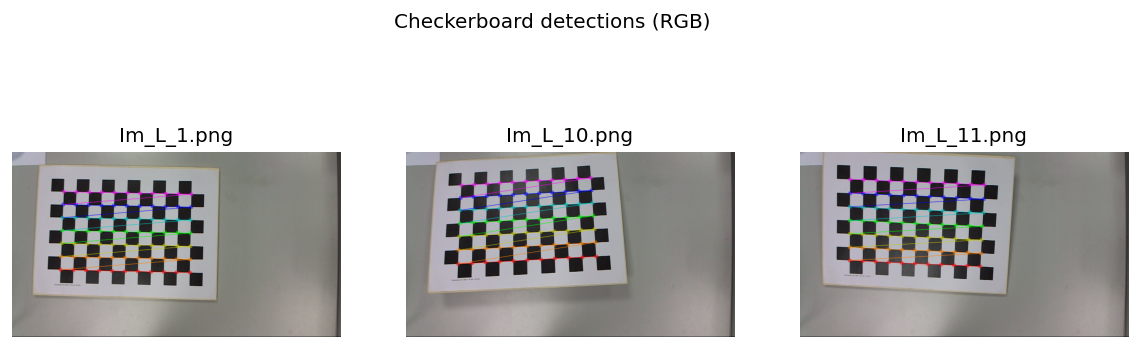


=== Calibration summary ===
Images used: 20
RMS reprojection error: 0.1994 px
Mean | Median reprojection: 0.0225 | 0.0236 px
Intrinsic matrix K:
 [[722.05334448   0.         513.69596477]
 [  0.         732.72851838 292.73912344]
 [  0.           0.           1.        ]]
Distortion coefficients [k1 k2 p1 p2 k3]: [ 0.01107271 -0.13692806 -0.00141524  0.00129919  0.20234508]


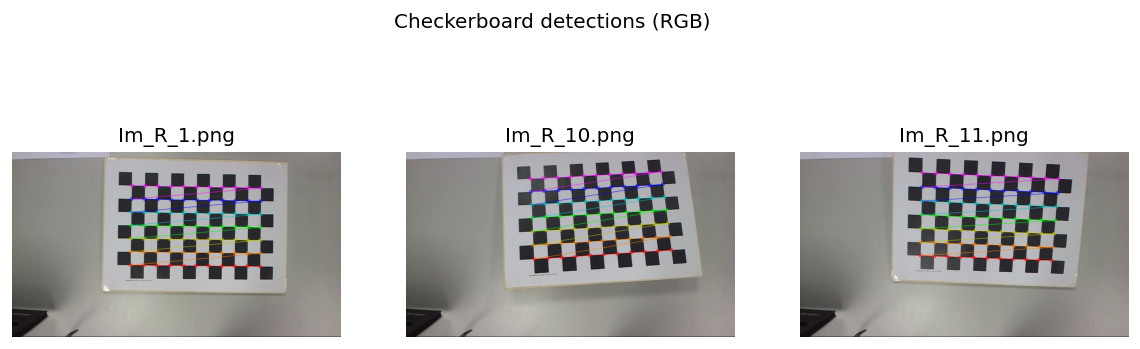

In [ ]:
results_left = calibrate_from_paths(
    img_files["left"],
    pattern_size=pattern_left,
    square_size=1.0,
    display_samples=3,
    verbose=True,
 )
results_right = calibrate_from_paths(
    img_files["right"],
    pattern_size=pattern_right,
    square_size=1.0,
    display_samples=3,
    verbose=True,
 )

In [51]:
summary_df = pd.DataFrame(
    {
        "left": {
            "images_used": results_left["images_used"],
            "rms_px": results_left["rms"],
            "mean_reproj_px": results_left["reproj_errors"].mean(),
            "median_reproj_px": np.median(results_left["reproj_errors"]),
        },
        "right": {
            "images_used": results_right["images_used"],
            "rms_px": results_right["rms"],
            "mean_reproj_px": results_right["reproj_errors"].mean(),
            "median_reproj_px": np.median(results_right["reproj_errors"]),
        },
    }
)
display(summary_df.round(4))

,left,right
images_used,20.0000,20.0000
rms_px,0.1860,0.1994
mean_reproj_px,0.0210,0.0225
median_reproj_px,0.0212,0.0236


In [58]:
# print("Left camera intrinsics", results_left["K"], results_left["dist"])
# print("Right camera intrinsics", results_right["K"], results_right["dist"])

print(
f"""
Left camera intrinsics (K, dist):
{results_left["K"]}
{results_left["dist"]}

Right camera intrinsics (K, dist):
{results_right["K"]}
{results_right["dist"]}
""")


Left camera intrinsics (K, dist):
[[718.91204079   0.         523.81798132]
 [  0.         729.96156577 285.67584618]
 [  0.           0.           1.        ]]
[[ 3.10695418e-02 -1.79731072e-01  8.73936668e-04  1.77047642e-04
   2.13763417e-01]]

Right camera intrinsics (K, dist):
[[722.05334448   0.         513.69596477]
 [  0.         732.72851838 292.73912344]
 [  0.           0.           1.        ]]
[[ 0.01107271 -0.13692806 -0.00141524  0.00129919  0.20234508]]

